In [3]:
# Setup
%load_ext autoreload
%autoreload 2

from eeg_toolkit import load_config
from eeg_toolkit import compute_rdms_all, load_all_rdms

cfg = load_config('../../configs/eye_eeg_simul.yaml')
print("Setup OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Setup OK


In [5]:
# ── Spatial block: 12 conditions (digit × position, excluding diagonal) ──
conditions_spatial = {
    "d1p2": [12], "d1p3": [13], "d1p4": [14],
    "d2p1": [21], "d2p3": [23], "d2p4": [24],
    "d3p1": [31], "d3p2": [32], "d3p4": [34],
    "d4p1": [41], "d4p2": [42], "d4p3": [43],
}

summary, group_spatial = compute_rdms_all(
    cfg,
    window_name="cue",
    conditions=conditions_spatial,
    analysis_name="spatial",
    resample_sfreq=256,
    baseline=(-0.2, 0.0),
    method="crossnobis",
    n_jobs=1,
    overwrite=True,
)

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Computing RDMs for 30 subject(s)

--- [1/30] subj3 ---
   [subj3] 120 trials: d1p2=7, d1p3=4, d1p4=12, d2p1=12, d2p3=8, d2p4=10, d3p1=8, d3p2=10, d3p4=9, d4p1=8, d4p2=14, d4p3=18
   [subj3] balanced to 4 per condition
   [subj3] computing crossnobis RDM movie (12 conditions, 32 channels, 462 time points)...
   [subj3] saved: subj3_cue_rsa_spatial.npz (462 time points, 66 pairs)

--- [2/30] subj4 ---
   [subj4] 120 trials: d1p2=6, d1p3=11, d1p4=13, d2p1=11, d2p3=9, d2p4=8, d3p1=10, d3p2=13, d3p4=10, d4p1=7, d4p2=12, d4p3=10
   [subj4] balanced to 6 per condition
   [subj4] computing crossnobis RDM movie (12 conditions, 32 channels, 462 time points)...
   [subj4] saved: subj4_cue_rsa_spatial.npz (462 time points, 66 pairs)

--- [3/30] subj5 ---
   [subj5] 120 trials: d1p2=13, d1p3=4, d1p4=11, d2p1=9, d2p3=14, d2p4=10, d3p1=10, d3p2=7, d3p4=10, d4p1=9, d4p2=11, d4p3=12
   

In [6]:
# ── Symbolic block: 12 conditions (same structure, +100 offset) ──
conditions_symbolic = {
    "d1p2": [112], "d1p3": [113], "d1p4": [114],
    "d2p1": [121], "d2p3": [123], "d2p4": [124],
    "d3p1": [131], "d3p2": [132], "d3p4": [134],
    "d4p1": [141], "d4p2": [142], "d4p3": [143],
}

summary, group_symbolic = compute_rdms_all(
    cfg,
    window_name="cue",
    conditions=conditions_symbolic,
    analysis_name="symbolic",
    resample_sfreq=256,
    baseline=(-0.2, 0.0),
    method="crossnobis",
    n_jobs=1,
    overwrite=True,
)

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Computing RDMs for 30 subject(s)

--- [1/30] subj3 ---
   [subj3] 120 trials: d1p2=16, d1p3=11, d1p4=6, d2p1=10, d2p3=8, d2p4=9, d3p1=9, d3p2=10, d3p4=11, d4p1=12, d4p2=8, d4p3=10
   [subj3] balanced to 6 per condition
   [subj3] computing crossnobis RDM movie (12 conditions, 32 channels, 462 time points)...
   [subj3] saved: subj3_cue_rsa_symbolic.npz (462 time points, 66 pairs)

--- [2/30] subj4 ---
   [subj4] 120 trials: d1p2=9, d1p3=10, d1p4=14, d2p1=11, d2p3=5, d2p4=11, d3p1=14, d3p2=6, d3p4=10, d4p1=8, d4p2=12, d4p3=10
   [subj4] balanced to 5 per condition
   [subj4] computing crossnobis RDM movie (12 conditions, 32 channels, 462 time points)...
   [subj4] saved: subj4_cue_rsa_symbolic.npz (462 time points, 66 pairs)

--- [3/30] subj5 ---
   [subj5] 120 trials: d1p2=14, d1p3=11, d1p4=8, d2p1=10, d2p3=8, d2p4=9, d3p1=10, d3p2=9, d3p4=11, d4p1=6, d4p2=12, d4p3=12
 

In [7]:
import numpy as np
from eeg_toolkit.rsa import square_to_vec

# ── Extract digit and position from condition labels ──
# Condition order matches the sorted dict keys
cond_names = sorted(conditions_spatial.keys())  # same order for both blocks
n_cond = len(cond_names)

digits = np.array([int(c[1]) for c in cond_names])     # d{X}p{Y} → X
positions = np.array([int(c[3]) for c in cond_names])   # d{X}p{Y} → Y

# ── Build model RDMs (n_conditions × n_conditions) ──

# 1. Position distance (graded): |pos_i - pos_j|
position_distance = np.abs(positions[:, None] - positions[None, :]).astype(float)

# 2. Digit distance (graded): |dig_i - dig_j|
digit_distance = np.abs(digits[:, None] - digits[None, :]).astype(float)

# 3. Position identity (binary): 0 = same position, 1 = different
position_identity = (positions[:, None] != positions[None, :]).astype(float)

# 4. Digit identity (binary): 0 = same digit, 1 = different
digit_identity = (digits[:, None] != digits[None, :]).astype(float)

# 5. Left-right (binary): positions 1,2 = left; 3,4 = right
sides = np.array([0 if p <= 2 else 1 for p in positions])
left_right = (sides[:, None] != sides[None, :]).astype(float)

# 6. Low-high (binary): digits 1,2 = low; 3,4 = high
magnitudes = np.array([0 if d <= 2 else 1 for d in digits])
low_high = (magnitudes[:, None] != magnitudes[None, :]).astype(float)

# ── Pack into a dict (square matrices, square_to_vec done internally) ──
models = {
    "Position distance": position_distance,
    "Digit distance": digit_distance,
    "Position identity": position_identity,
    "Digit identity": digit_identity,
    "Left–right": left_right,
    "Low–high": low_high,
}

# Quick check: correlations between models
from scipy.stats import spearmanr
print("Model correlations (upper-triangle vectors):")
model_vecs = {k: square_to_vec(v) for k, v in models.items()}
names = list(model_vecs.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        r, _ = spearmanr(model_vecs[names[i]], model_vecs[names[j]])
        print(f"  {names[i]:22s} × {names[j]:22s}: r = {r:.3f}")

Model correlations (upper-triangle vectors):
  Position distance      × Digit distance        : r = -0.114
  Position distance      × Position identity     : r = 0.703
  Position distance      × Digit identity        : r = -0.156
  Position distance      × Left–right            : r = 0.772
  Position distance      × Low–high              : r = -0.035
  Digit distance         × Position identity     : r = -0.156
  Digit distance         × Digit identity        : r = 0.703
  Digit distance         × Left–right            : r = -0.035
  Digit distance         × Low–high              : r = 0.772
  Position identity      × Digit identity        : r = -0.222
  Position identity      × Left–right            : r = 0.516
  Position identity      × Low–high              : r = -0.115
  Digit identity         × Left–right            : r = -0.115
  Digit identity         × Low–high              : r = 0.516
  Left–right             × Low–high              : r = 0.022


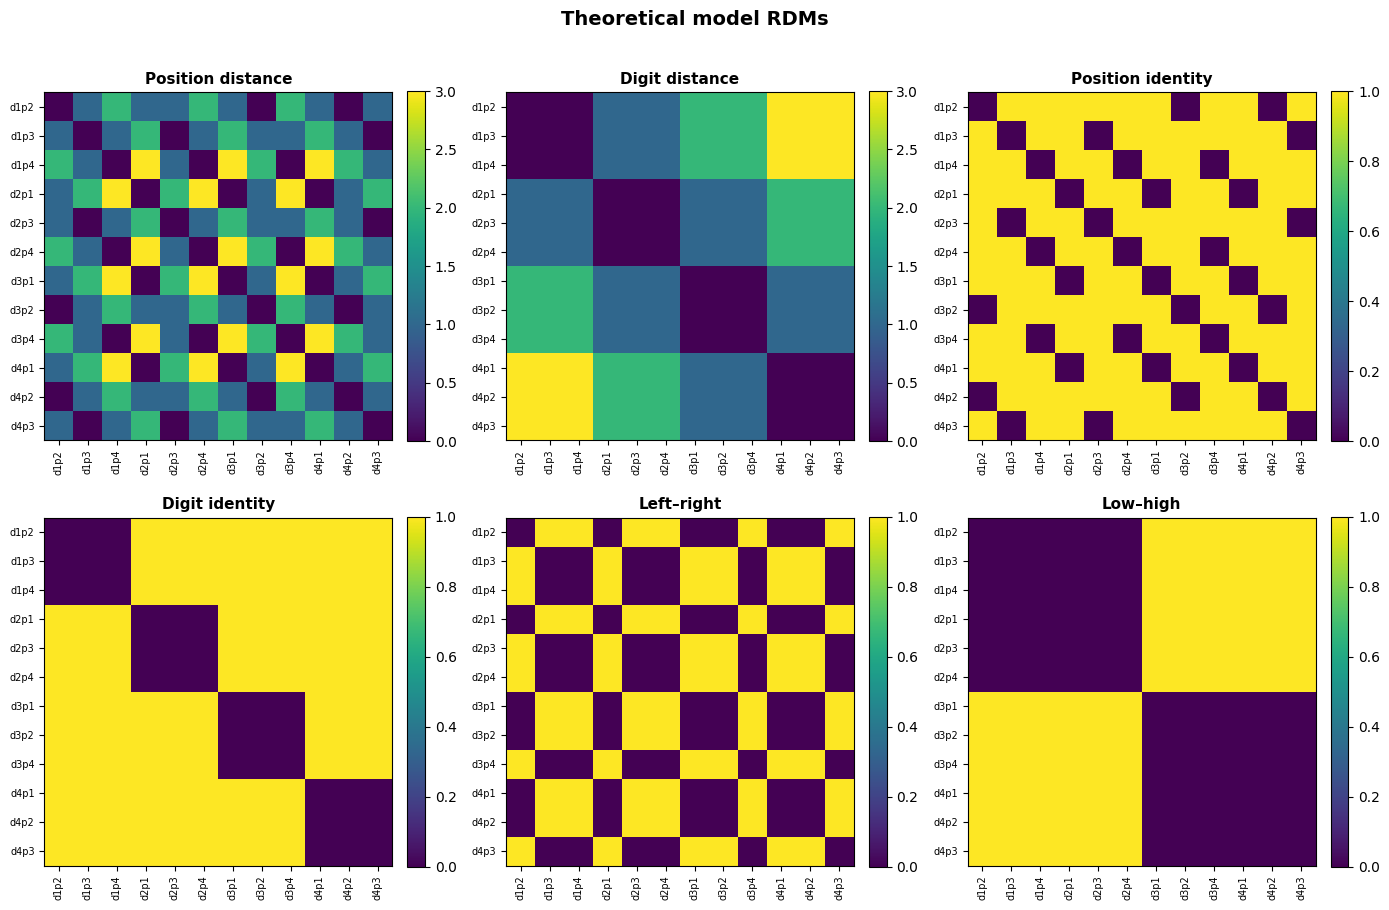

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for ax, (name, mat) in zip(axes, models.items()):
    im = ax.imshow(mat, cmap="viridis", aspect="equal")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_xticks(range(n_cond))
    ax.set_yticks(range(n_cond))
    ax.set_xticklabels(cond_names, rotation=90, fontsize=7)
    ax.set_yticklabels(cond_names, fontsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Theoretical model RDMs", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()
plt.show()

[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, shape: (30, 462, 66)
[find_subjects] excluded 8 subject(s): ['subj13', 'subj15', 'subj16', 'subj17', 'subj2', 'subj20', 'subj28', 'subj7']
Loaded 30 subjects, shape: (30, 462, 66)


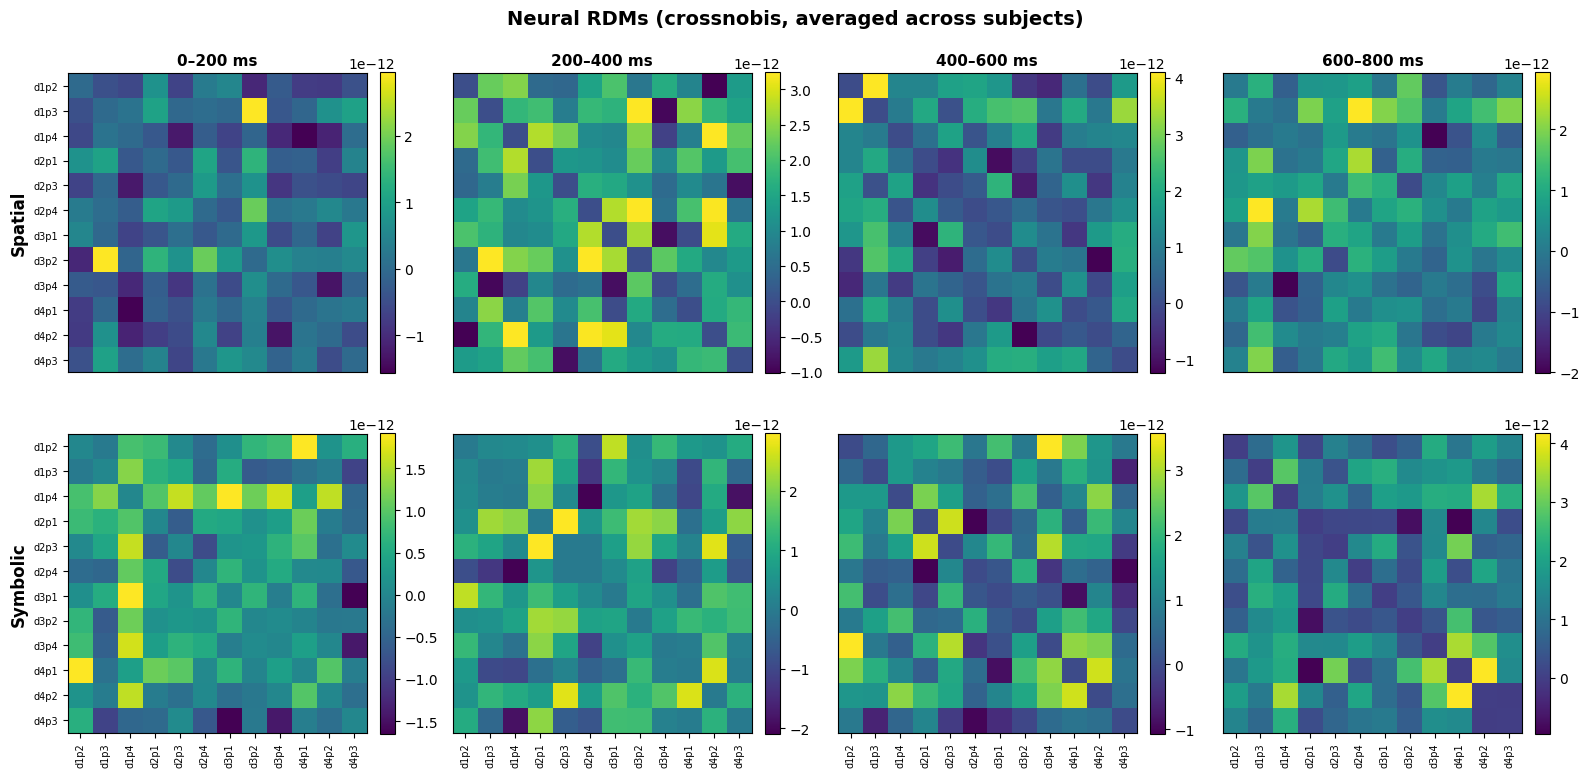

In [9]:
from eeg_toolkit.rsa import load_all_rdms, vec_to_square

group_spatial = load_all_rdms(cfg, "cue", "spatial")
group_symbolic = load_all_rdms(cfg, "cue", "symbolic")

times = group_spatial["times"]
cond_names = list(group_spatial["condition_names"])
n_cond = group_spatial["n_conditions"]

# ── Time windows to display ──
time_windows = [
    ("0–200 ms", 0.0, 0.2),
    ("200–400 ms", 0.2, 0.4),
    ("400–600 ms", 0.4, 0.6),
    ("600–800 ms", 0.6, 0.8),
]

fig, axes = plt.subplots(2, len(time_windows), figsize=(16, 8))

for col, (label, tmin, tmax) in enumerate(time_windows):
    t_mask = (times >= tmin) & (times <= tmax)

    for row, (group, block_name) in enumerate([
        (group_spatial, "Spatial"),
        (group_symbolic, "Symbolic"),
    ]):
        # Average across subjects and time window
        mean_vec = group["dissimilarities"][:, t_mask, :].mean(axis=(0, 1))
        rdm_mat = vec_to_square(mean_vec, n_cond)

        ax = axes[row, col]
        im = ax.imshow(rdm_mat, cmap="viridis", aspect="equal")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        if col == 0:
            ax.set_ylabel(block_name, fontsize=12, fontweight="bold")
            ax.set_yticks(range(n_cond))
            ax.set_yticklabels(cond_names, fontsize=7)
        else:
            ax.set_yticks([])

        if row == 0:
            ax.set_title(label, fontsize=11, fontweight="bold")

        if row == 1:
            ax.set_xticks(range(n_cond))
            ax.set_xticklabels(cond_names, rotation=90, fontsize=7)
        else:
            ax.set_xticks([])

fig.suptitle("Neural RDMs (crossnobis, averaged across subjects)",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()